AdaBoost                    0.7857    |   0.8000   
AdaBoost + PCA              0.6667    |   0.8000   
Logistic Regression         0.7857    |   0.6500   
Random Forest               0.7381    |   0.7000   


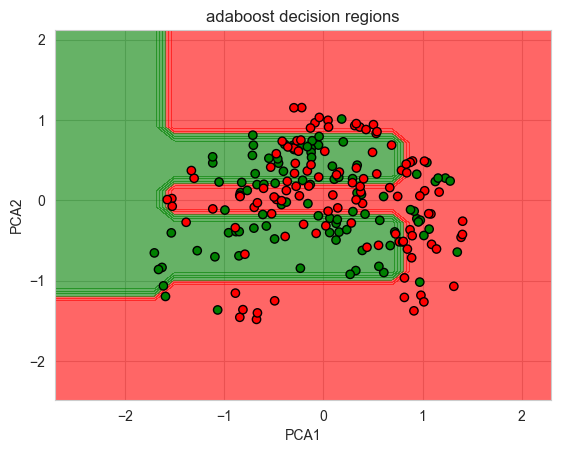

In [12]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from AdaBoost import AdaBoost 
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, accuracy_score
from sklearn.decomposition import PCA 
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.datasets import load_wine

df = pd.read_csv('Sonar.csv', header=None)

le = LabelEncoder()
X = df.iloc[:, range(0, 60)].values
y = le.fit_transform(df.iloc[:, 60].values)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=0)

ada = AdaBoost()
ada.fit(X_train, y_train)
# print(f'{'AdaBoost':^25}')
# print(f'{accuracy_score(y_test, ada.predict(X_test)):.4f} | 0.7619')
# print(f'{recall_score(y_test, ada.predict(X_test)):.4f} | 0.7000')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca, y, test_size=0.2, stratify=y, random_state=0)

ada2 = AdaBoost()
ada2.fit(X_train_pca, y_train_pca)
# print(f'{'AdaBoost with PCA':^25}')
# print(f'{accuracy_score(y_test_pca, ada2.predict(X_test_pca)):.4f} | 0.6190')
# print(f'{recall_score(y_test_pca, ada2.predict(X_test_pca)):.4f} | 0.6000')

sns.set_style('whitegrid')
def plot_decision_regions(X, y, estimator):
    markers = ('o', '^')
    colors = ('red', 'green')
    cmap = ListedColormap(colors[:len(np.unique(y))])
      
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.2),
                         np.arange(y_min, y_max, 0.2))
    Z = estimator.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, cmap=cmap, alpha=0.6)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cmap, edgecolors='black')
    plt.xlabel('PCA1')
    plt.ylabel('PCA2')
    plt.title('adaboost decision regions')

plot_decision_regions(X_pca, y, ada2)
    
pipe_lr = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

pipe_lr.fit(X_train, y_train)
# print(f'{'LogisticRegression':^25}')
# print(f'lr {accuracy_score(y_test, pipe_lr.predict(X_test)):.4f} | 0.7857')
# print(f'lr {recall_score(y_test, pipe_lr.predict(X_test)):.4f} | 0.6500')

rf = RandomForestClassifier(n_estimators=500, max_depth=4, n_jobs=-1, random_state=0)
rf.fit(X_train, y_train)
# print(f'{'RandomForestClassifier':^25}')
# print(f'rf {accuracy_score(y_test, rf.predict(X_test)):.4f}')
# print(f'rf {recall_score(y_test, rf.predict(X_test)):.4f}')
def printer():
    # AdaBoost
    print(f"{'AdaBoost':<25} {accuracy_score(y_test, ada.predict(X_test)):^11.4f} | {recall_score(y_test, ada.predict(X_test)):^11.4f}")
    
    # AdaBoost + PCA
    print(f"{'AdaBoost + PCA':<25} {accuracy_score(y_test_pca, ada2.predict(X_test_pca)):^11.4f} | {recall_score(y_test_pca, ada2.predict(X_test_pca)):^11.4f}")

    # Logistic Regression
    print(f"{'Logistic Regression':<25} {accuracy_score(y_test, pipe_lr.predict(X_test)):^11.4f} | {recall_score(y_test, pipe_lr.predict(X_test)):^11.4f}")

    # Random Forest
    print(f"{'Random Forest':<25} {accuracy_score(y_test, rf.predict(X_test)):^11.4f} | {recall_score(y_test, rf.predict(X_test)):^11.4f}")

printer()

accuracy_score(train) : 0.928
accuracy_score(test)  : 0.861
accuracy_score(train) : 0.976
accuracy_score(test)  : 0.889


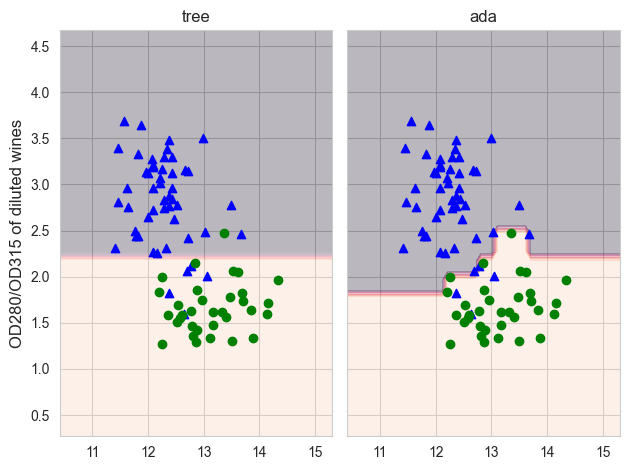

[0 1]


In [24]:
from sklearn.ensemble import AdaBoostClassifier 
from sklearn.tree import DecisionTreeClassifier

tree = DecisionTreeClassifier(criterion='entropy', max_depth=1, random_state=1)
ada = AdaBoostClassifier(n_estimators=500,
                         learning_rate=0.1,
                         random_state=1)
df_wine = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/wine/wine.data', header=None)
df_wine.columns = [
    'class',          # сорт вина (0, 1, 2) - целевая переменная
    'alcohol',        # алкоголь
    'malic_acid',     # яблочная кислота
    'ash',           # зольность
    'alcalinity_of_ash', # щелочность золы
    'magnesium',      # магний
    'total_phenols',  # общие фенолы
    'flavanoids',     # флавоноиды
    'nonflavanoid_phenols', # нефлавоноидные фенолы
    'proanthocyanins',# проантоцианины
    'color_intensity',# интенсивность цвета
    'hue',            # оттенок
    'od280_od315_of_diluted_wines',
    'proline' # оптическая плотность
]
df_wine = df_wine[df_wine['class'] != 1]
y = df_wine['class'].values
X = df_wine[['alcohol', 'od280_od315_of_diluted_wines']].values 
leb = LabelEncoder()
y = leb.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, random_state=1, test_size=0.3)
 
tree = tree.fit(X_train, y_train)
y_train_pred = tree.predict(X_train)
y_test_pred = tree.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f"accuracy_score(train) : {tree_train:.3f}\naccuracy_score(test)  : {tree_test:.3f}")

ada = ada.fit(X_train, y_train)
y_train_pred = ada.predict(X_train)
y_test_pred = ada.predict(X_test)
tree_train = accuracy_score(y_train, y_train_pred)
tree_test = accuracy_score(y_test, y_test_pred)
print(f"accuracy_score(train) : {tree_train:.3f}\naccuracy_score(test)  : {tree_test:.3f}")

x_min = X_train[:, 0].min() - 1
x_max = X_train[:, 0].max() + 1
y_min = X_train[:, 1].min() - 1
y_max = X_train[:, 1].max() + 1

xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), 
                     np.arange(y_min, y_max, 0.1))
fig, ax = plt.subplots(1, 2, 
                       sharex='col',
                       sharey='row')
for idx, clf, tt in zip([0,1], 
                        [tree, ada], 
                        ['tree', 'ada']):
    clf.fit(X_train, y_train)
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax[idx].contourf(xx, yy, Z, alpha=0.3)
    ax[idx].scatter(X_train[y_train==0, 0],
                    X_train[y_train==0, 1],
                    c='blue',
                    marker='^')
    ax[idx].scatter(X_train[y_train==1, 0],
                    X_train[y_train==1, 1],
                    c='green',
                    marker='o')
    ax[idx].set_title(tt)
    ax[0].set_ylabel('OD280/OD315 of diluted wines', fontsize=12)
    
plt.tight_layout()
plt.show()
    
print(np.unique(y))
